In [6]:
import mne
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib qt

file_path = "Test 1 Water_EPOCX_812190_2026.06.04T16.34.11+08.00.edf"
raw_eeg = mne.io.read_raw_edf(file_path, preload=True)

Extracting EDF parameters from Test 1 Water_EPOCX_812190_2026.06.04T16.34.11+08.00.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 12799  =      0.000 ...    99.992 secs...


In [7]:
eeg_channels = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
raw_eeg.pick_channels(eeg_channels)

montage = mne.channels.make_standard_montage("standard_1020")
raw_eeg.set_montage(montage)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<RawEDF | Test 1 Water_EPOCX_812190_2026.06.04T16.34.11+08.00.edf, 14 x 12800 (100.0 s), ~1.4 MiB, data loaded>

Channels marked as bad:
none


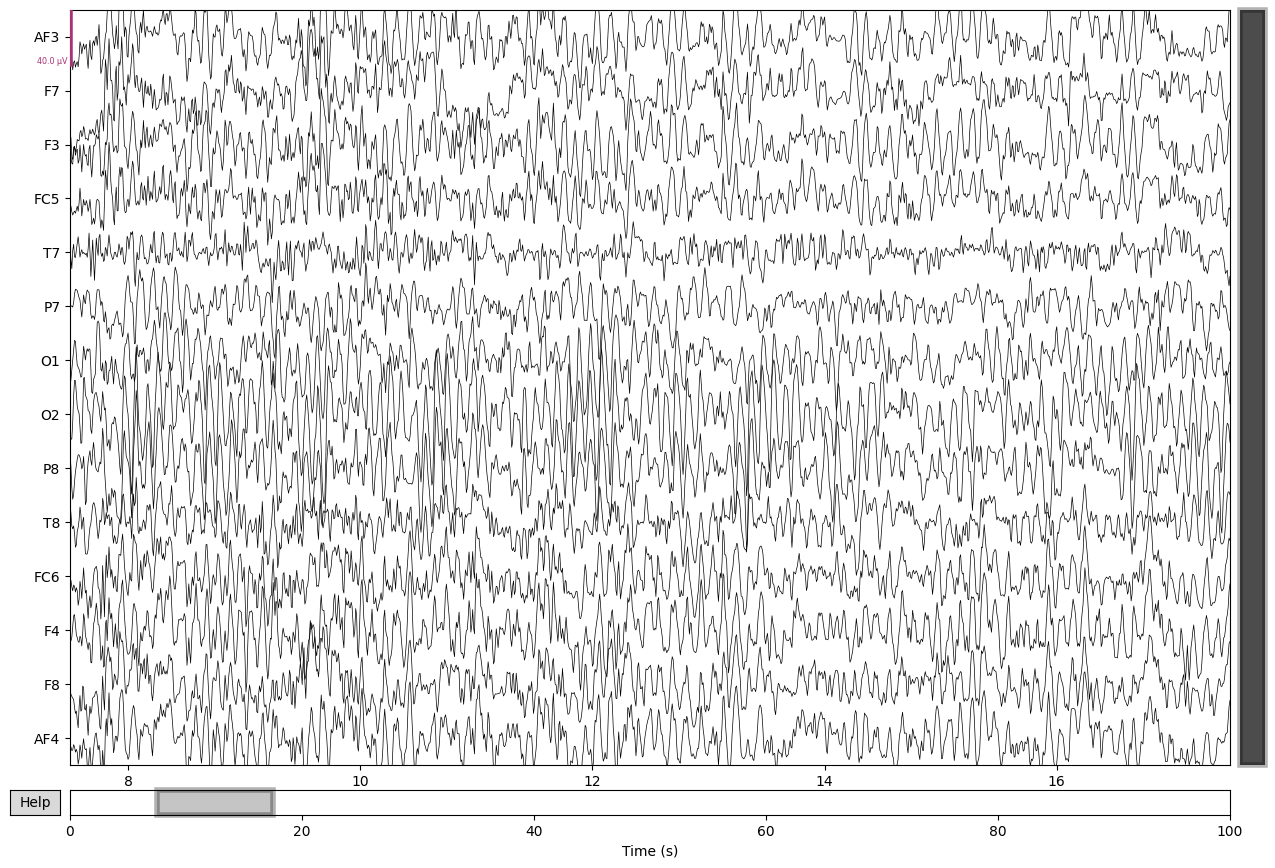

In [11]:
raw_eeg.plot(block=True, duration=10)

### Preprocessing

In [12]:
raw_eeg.filter(l_freq=1.0, h_freq=40.0, fir_design="firwin")
raw_eeg.notch_filter(freqs=50.0, fir_design="firwin")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 423 samples (3.305 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge

<RawEDF | Test 1 Water_EPOCX_812190_2026.06.04T16.34.11+08.00.edf, 14 x 12800 (100.0 s), ~1.4 MiB, data loaded>

In [ ]:
# Eyes opened, holding the food or drinks
holding_state = raw_eeg.copy().crop(tmin=0.0, tmax=6.0)

# Eyes closed, after swalloed the food or drinks
relaxed_state = raw_eeg.copy().crop(tmin=10.0, tmax=16.0)